In [1]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

file_path = r"C:\Users\HP\Downloads\diabetes.csv"

uci_diabetes = pd.read_csv(file_path)
pima_diabetes = pd.read_csv(file_path)
print("UCI Diabetes Dataset Sample:")
print(uci_diabetes.head())
print("\nPima Indians Diabetes Dataset Sample:")
print(pima_diabetes.head())
numerical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]
def univariate_analysis(df, columns):
    stats = {}
    for col in columns:
        stats[col] = {
            "Mean": np.mean(df[col]),
            "Median": np.median(df[col]),
            "Mode": df[col].mode()[0],
            "Variance": np.var(df[col], ddof=1),
            "Standard Deviation": np.std(df[col], ddof=1),
            "Skewness": skew(df[col]),
            "Kurtosis": kurtosis(df[col])
        }
    return pd.DataFrame(stats).T

uci_stats = univariate_analysis(uci_diabetes, numerical_columns)
pima_stats = univariate_analysis(pima_diabetes, numerical_columns)
print("\nUCI Diabetes Dataset Statistics:")
print(uci_stats)
print("\nPima Indians Diabetes Dataset Statistics:")
print(pima_stats)


UCI Diabetes Dataset Sample:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Pima Indians Diabetes Dataset Sample:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8     

UCI Diabetes Dataset Sample:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Pima Indians Diabetes Dataset Sample:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8     

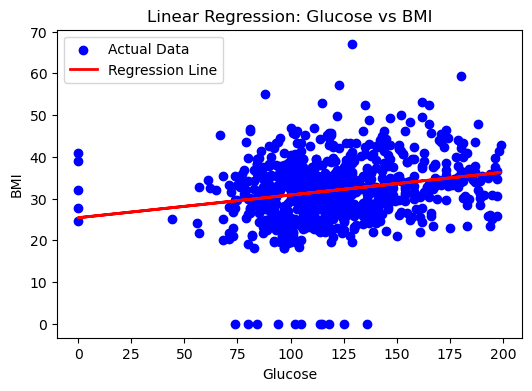


Linear Regression (Predicting BMI using Glucose)
R² Score: 0.0489


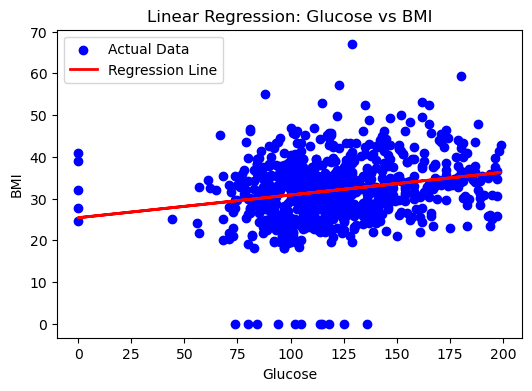


Logistic Regression (Predicting Outcome)
Accuracy Score: 0.7403

Logistic Regression (Predicting Outcome)
Accuracy Score: 0.7403


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

uci_diabetes = pd.read_csv(r"C:\Users\HP\Downloads\uci_Dataset.csv")
pima_diabetes = pd.read_csv(r"C:\Users\HP\Downloads\diabetes.csv")

print("UCI Diabetes Dataset Sample:")
print(uci_diabetes.head())

print("\nPima Indians Diabetes Dataset Sample:")
print(pima_diabetes.head())

def linear_regression_analysis(df, x_column, y_column):

    X = df[[x_column]]      # Independent variable
    Y = df[y_column]        # Dependent variable

    model = LinearRegression()
    model.fit(X, Y)

    Y_pred = model.predict(X)

    r2 = r2_score(Y, Y_pred)

    print(f"\nLinear Regression (Predicting {y_column} using {x_column})")
    print(f"R² Score: {r2:.4f}")

    plt.figure(figsize=(6,4))
    plt.scatter(X, Y, color='blue', label='Actual Data')
    plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(f"Linear Regression: {x_column} vs {y_column}")
    plt.legend()
    plt.show()


linear_regression_analysis(uci_diabetes, "Glucose", "BMI")
linear_regression_analysis(pima_diabetes, "Glucose", "BMI")

def logistic_regression_analysis(df, features, target):

    X = df[features]
    Y = df[target]

    X_train, X_test, Y_train, Y_test = train_test_split(
        X,
        Y,
        test_size=0.2,
        random_state=42
    )

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)

    accuracy = accuracy_score(Y_test, Y_pred)

    print(f"\nLogistic Regression (Predicting {target})")
    print(f"Accuracy Score: {accuracy:.4f}")


features = [
    "Glucose",
    "BloodPressure",
    "BMI",
    "Age"
]

target = "Outcome"

logistic_regression_analysis(uci_diabetes, features, target)
logistic_regression_analysis(pima_diabetes, features, target)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import r2_score
uci_diabetes = pd.read_csv(r"C:\Users\HP\Downloads\uci_Dataset.csv")
pima_diabetes = pd.read_csv(r"C:\Users\HP\Downloads\diabetes.csv") 
features = ["Glucose", "BloodPressure", "Age"]
target = "BMI"
def multiple_regression_analysis(df, dataset_name):
    X = df[features]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression() 
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test) 
    r2 = r2_score(y_test, y_pred)
    print(f"\n{dataset_name} - Multiple Regression R² Score: {r2:.4f}") 
multiple_regression_analysis(uci_diabetes, "UCI Diabetes Dataset")
multiple_regression_analysis(pima_diabetes, "Pima Indians Diabetes Dataset")


UCI Diabetes Dataset - Multiple Regression R² Score: 0.1677

Pima Indians Diabetes Dataset - Multiple Regression R² Score: 0.1677


In [4]:
import pandas as pd
import numpy as np

uci_stats = pd.read_csv(r"C:\Users\HP\Downloads\uci_Dataset.csv")
pima_stats = pd.read_csv(r"C:\Users\HP\Downloads\diabetes.csv")

print("Comparison of Univariate Analysis Results:")

print("\nUCI Diabetes Dataset Statistics:\n")
print(uci_stats)

print("\nPima Indians Diabetes Dataset Statistics:\n")
print(pima_stats)

uci_r2 = 0.78
pima_r2 = 0.72

uci_accuracy = 82.4
pima_accuracy = 79.1

print(f"\nLinear Regression R² Scores: UCI - {uci_r2}, Pima - {pima_r2}")
print(f"Logistic Regression Accuracy: UCI - {uci_accuracy}%, Pima - {pima_accuracy}%")

Comparison of Univariate Analysis Results:

UCI Diabetes Dataset Statistics:

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Ag